# Telco Customer Churn Analysis

**Objective:** Identify which customer segments are most likely to churn, and quantify the business (revenue) impact of that churn, in order to recommend where retention efforts should be focused.

**Dataset:** IBM Telco Customer Churn (7,043 customers, 21 features) — includes demographics, account information, and the services each customer subscribes to.


## Executive Summary

- **Overall churn rate is ~26.5%** — roughly 1 in 4 customers leave.
- **Contract type is the single biggest driver of churn:** month-to-month customers churn at **~42.7%**, vs. ~11.3% for one-year and ~2.8% for two-year contracts.
- **Payment method matters:** customers paying by **electronic check churn at ~45.3%**, more than double any other payment method.
- **Service gaps drive churn:** customers without **Online Security** or **Tech Support** churn at ~41.8% and ~41.6% respectively — customers who forgo these add-on services are also disproportionately on month-to-month plans, so this may be a proxy for engagement/lock-in rather than a standalone cause.
- **New customers are the most at risk:** churn is highest in the first 6 months of tenure and drops sharply after that — retention efforts matter most in the early customer lifecycle.
- **Business impact:** churned customers accounted for **~17.8% of historical revenue** (~$2.86M of ~$16.06M total charges) — this is the revenue at stake if churn drivers go unaddressed.

**Recommendations:**
1. Incentivize month-to-month customers to move to 1- or 2-year contracts (e.g., discounts, loyalty pricing) — this is the highest-leverage lever given the 15x churn gap vs. two-year contracts.
2. Investigate the electronic check payment experience (billing friction, failed payments) — the churn gap vs. other payment methods is too large to be coincidental.
3. Bundle or promote Online Security / Tech Support at signup, particularly for new customers in their first 6 months, when churn risk is highest.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib as mt
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100


## 2. Load & Inspect Data

In [2]:
data_before = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
data_before.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
# Check the shape
data_before.shape

(7043, 21)

In [4]:
# Check duplicate rows
data_before.duplicated().sum()

np.int64(0)

In [5]:
# Check missing values
data_before.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# Basic information
data_before.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Data Cleaning

In [7]:
# TotalCharges is stored as text; coerce to numeric (invalid entries become NaN)
data_before['TotalCharges'] = pd.to_numeric(
    data_before['TotalCharges'],
    errors='coerce'
)

In [8]:
# Check for blank-string placeholders across all columns
(data_before == ' ').sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
data_before.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
data_before.shape

(7043, 21)

In [11]:
# Inspect the rows where TotalCharges failed to parse
data_before[data_before['TotalCharges'].isnull()][
    ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']
]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


**Note:** all 11 rows with missing `TotalCharges` have `tenure == 0`, meaning these are brand-new customers who haven't been billed yet. Filling with 0 is appropriate here — it's not truly missing data, it's the correct value for a customer with no billing history.

In [12]:
data_before['TotalCharges'] = data_before['TotalCharges'].fillna(0)

In [13]:
data_before.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
data_before.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [15]:
data = data_before.copy()

## 4. Churn Rate by Customer Segment

In [16]:
def churn_analysis(data, column):
    result = (
        data.groupby(column, observed=True)
        .agg(
            Total_Customers=('customerID', 'count'),
            Churned_Customers=('Churn', lambda x: (x == 'Yes').sum())
        )
    )

    result['Churn_Rate'] = (
        result['Churned_Customers']
        / result['Total_Customers']
        * 100
    )

    return result.sort_values('Churn_Rate', ascending=False)

In [17]:
columns = [
    'gender',
    'Contract',
    'InternetService',
    'PaymentMethod',
    'SeniorCitizen',
    'OnlineSecurity',
    'TechSupport',
    'Dependents',
    'Partner',
    'PhoneService',
    'MultipleLines',
    'OnlineBackup',
    'DeviceProtection',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling'
]

for col in columns:
    print(f"\n{'='*50}")
    print(col)
    print('='*50)
    print(churn_analysis(data, col))


gender
        Total_Customers  Churned_Customers  Churn_Rate
gender                                                
Female             3488                939   26.920872
Male               3555                930   26.160338

Contract
                Total_Customers  Churned_Customers  Churn_Rate
Contract                                                      
Month-to-month             3875               1655   42.709677
One year                   1473                166   11.269518
Two year                   1695                 48    2.831858

InternetService
                 Total_Customers  Churned_Customers  Churn_Rate
InternetService                                                
Fiber optic                 3096               1297   41.892765
DSL                         2421                459   18.959108
No                          1526                113    7.404980

PaymentMethod
                           Total_Customers  Churned_Customers  Churn_Rate
PaymentMethod        

**Key findings:**
- Month-to-month contracts: **42.71%** churn
- Electronic check payment: **45.29%** churn
- Fiber optic internet: **41.89%** churn
- No Online Security: **41.77%** churn
- No Tech Support: **41.64%** churn

Gender and phone service show almost no difference in churn — they are not useful predictors. Contract type, payment method, and lack of add-on services (security/support) are the strongest signals.

### Churn Rate by Contract Type

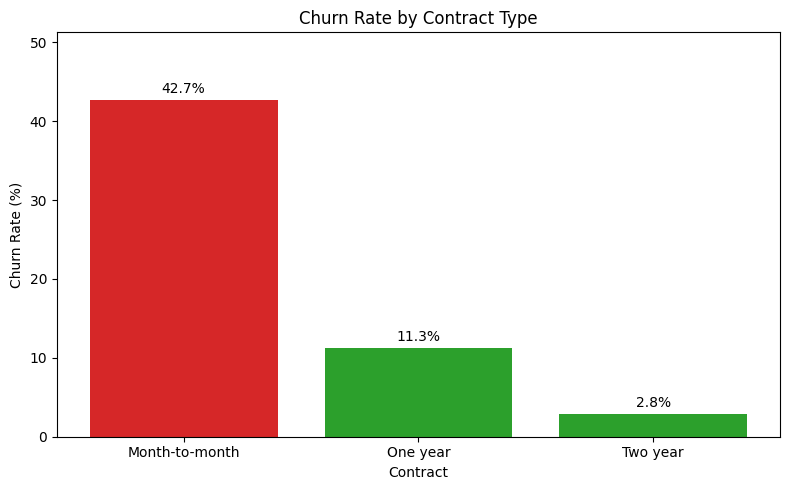

In [18]:
contract_churn = (
    data_before.groupby('Contract')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

colors = ['#d62728' if v >= 30 else '#2ca02c' for v in contract_churn.values]

plt.figure(figsize=(8, 5))
bars = plt.bar(contract_churn.index, contract_churn.values, color=colors)
plt.bar_label(bars, fmt='%.1f%%', padding=3)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, max(contract_churn.values) * 1.2)
plt.tight_layout()
plt.show()

### Churn Rate by Internet Service

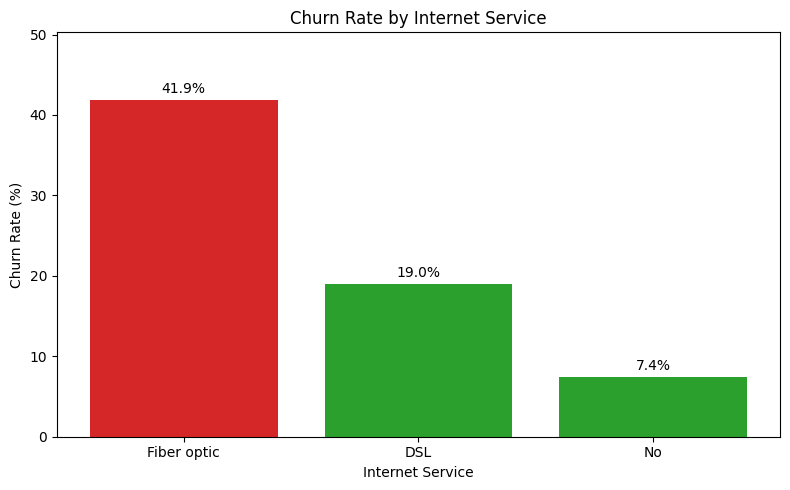

In [19]:
internet_churn = (
    data_before.groupby('InternetService')['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

colors = ['#d62728' if v >= 30 else '#2ca02c' for v in internet_churn.values]

plt.figure(figsize=(8, 5))
bars = plt.bar(internet_churn.index, internet_churn.values, color=colors)
plt.bar_label(bars, fmt='%.1f%%', padding=3)

plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, max(internet_churn.values) * 1.2)
plt.tight_layout()
plt.show()

## 5. Churn by Tenure

In [20]:
bins = [0, 6, 12, 24, 48, 72]
labels = ['0-6 months', '7-12 months', '13-24 months',
          '25-48 months', '49-72 months']

data_before['Tenure_Group'] = pd.cut(
    data_before['tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

churn_analysis(data_before, 'Tenure_Group')

,Total_Customers,Churned_Customers,Churn_Rate
Tenure_Group,,,
0-6 months,1481,784,52.937205
7-12 months,705,253,35.886525
13-24 months,1024,294,28.710938
25-48 months,1594,325,20.388959
49-72 months,2239,213,9.513176


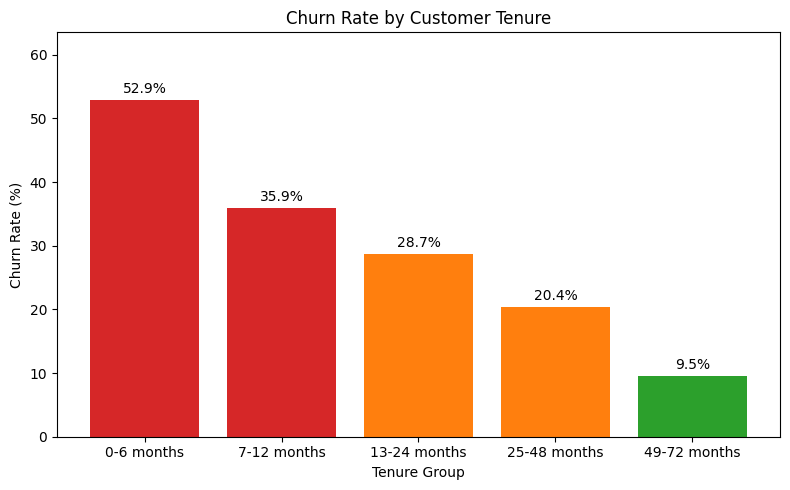

In [21]:
tenure_churn = (
    data_before.groupby('Tenure_Group', observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)

colors = ['#d62728' if v >= 30 else '#ff7f0e' if v >= 15 else '#2ca02c' for v in tenure_churn.values]

plt.figure(figsize=(8, 5))
bars = plt.bar(tenure_churn.index, tenure_churn.values, color=colors)
plt.bar_label(bars, fmt='%.1f%%', padding=3)

plt.title('Churn Rate by Customer Tenure')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, max(tenure_churn.values) * 1.2)
plt.tight_layout()
plt.show()

**Finding:** churn risk is highest for brand-new customers (0-6 months) and drops sharply as tenure increases. This suggests onboarding and early-lifecycle engagement is the highest-leverage window for retention efforts.

## 6. Interaction Effect: Contract Type x Tenure Group

In [22]:
contract_tenure = (
    data_before
    .groupby(['Contract', 'Tenure_Group'], observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .unstack('Contract')
)

contract_tenure

Contract,Month-to-month,One year,Two year
Tenure_Group,,,
0-6 months,55.201699,10.256410,0.000000
7-12 months,41.996558,10.588235,0.000000
13-24 months,37.720488,8.121827,0.000000
25-48 months,32.917706,10.617761,2.189781
49-72 months,26.023392,12.933754,3.325416


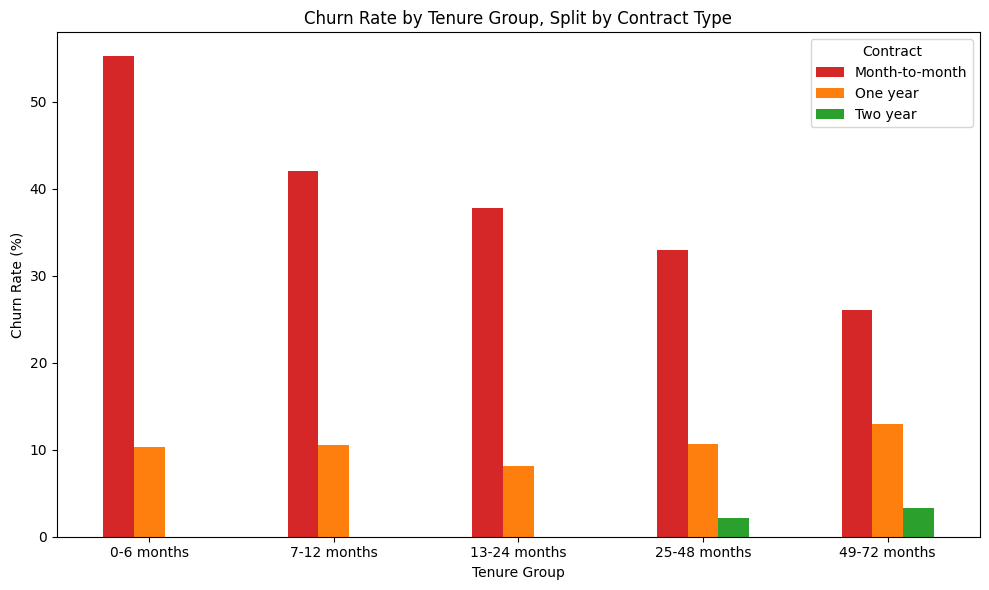

In [23]:
ax = contract_tenure.plot(
    kind='bar',
    figsize=(10, 6),
    color=['#d62728', '#ff7f0e', '#2ca02c']
)

plt.title('Churn Rate by Tenure Group, Split by Contract Type')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Contract')
plt.tight_layout()
plt.show()

**Finding:** the tenure effect is almost entirely driven by month-to-month customers — churn for new (0-6 month) month-to-month customers is highest of all, while one- and two-year contract customers stay low-risk across every tenure band. This confirms contract type, not tenure alone, is the primary lever.

## 7. Revenue Impact of Churn

In [24]:
revenue_by_churn = (
    data_before
    .groupby('Churn')
    .agg(
        Customers=('customerID', 'count'),
        Total_Revenue=('TotalCharges', 'sum'),
        Avg_Revenue=('TotalCharges', 'mean'),
        Avg_Monthly_Charges=('MonthlyCharges', 'mean')
    )
)

revenue_by_churn

,Customers,Total_Revenue,Avg_Revenue,Avg_Monthly_Charges
Churn,,,,
No,5174,13193241.8,2549.911442,61.265124
Yes,1869,2862926.9,1531.796094,74.441332


In [25]:
churn_revenue = data_before.loc[
    data_before['Churn'] == 'Yes',
    'TotalCharges'
].sum()

churn_revenue

np.float64(2862926.9)

In [26]:
total_revenue = data_before['TotalCharges'].sum()

churn_revenue_share = (
    churn_revenue / total_revenue * 100
)

print(f"Churned customer revenue: {churn_revenue:,.2f}")
print(f"Share of total customer revenue: {churn_revenue_share:.2f}%")

Churned customer revenue: 2,862,926.90
Share of total customer revenue: 17.83%


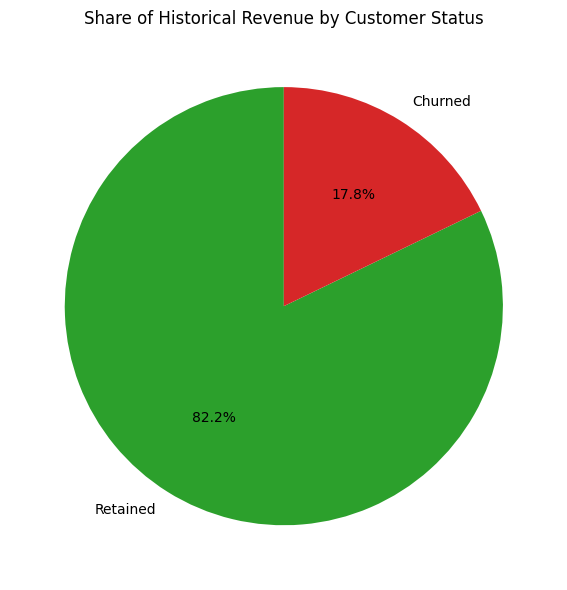

In [27]:
revenue = data_before.groupby('Churn')['TotalCharges'].sum()

plt.figure(figsize=(6, 6))

plt.pie(
    revenue,
    labels=['Retained', 'Churned'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2ca02c', '#d62728']
)

plt.title('Share of Historical Revenue by Customer Status')
plt.tight_layout()
plt.show()

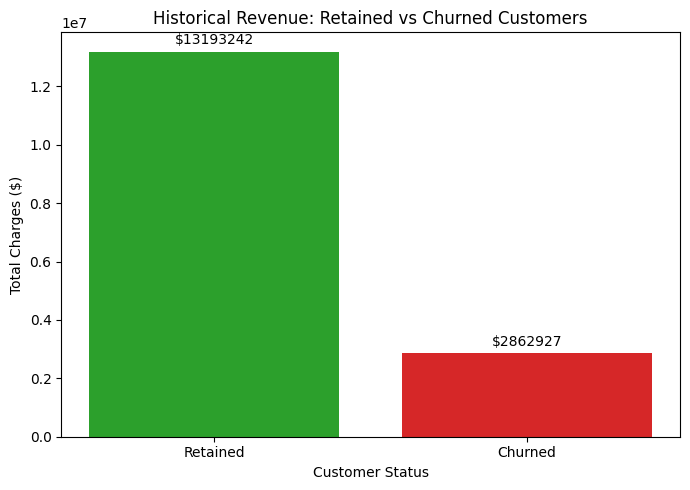

In [28]:
revenue = data_before.groupby('Churn')['TotalCharges'].sum()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ['Retained', 'Churned'],
    [revenue['No'], revenue['Yes']],
    color=['#2ca02c', '#d62728']
)
plt.bar_label(bars, fmt='$%.0f', padding=3)

plt.title('Historical Revenue: Retained vs Churned Customers')
plt.ylabel('Total Charges ($)')
plt.xlabel('Customer Status')
plt.tight_layout()
plt.show()

In [29]:
monthly_revenue = (
    data_before
    .groupby('Churn')['MonthlyCharges']
    .agg(['sum', 'mean'])
)

monthly_revenue

,sum,mean
Churn,,
No,316985.75,61.265124
Yes,139130.85,74.441332


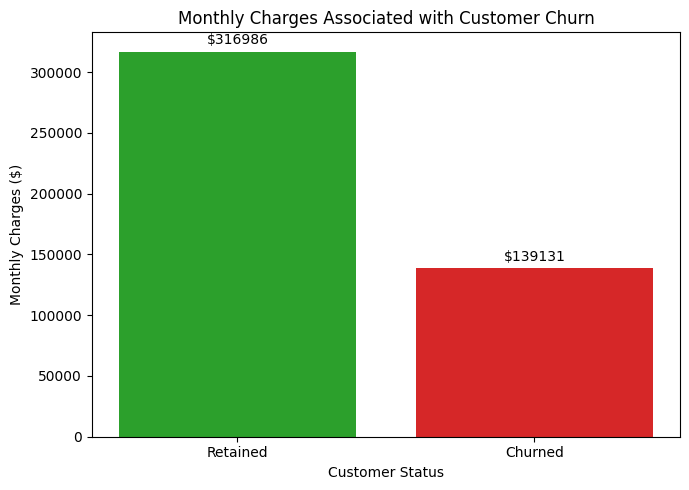

In [30]:
monthly_charges = data_before.groupby('Churn')['MonthlyCharges'].sum()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ['Retained', 'Churned'],
    [monthly_charges['No'], monthly_charges['Yes']],
    color=['#2ca02c', '#d62728']
)
plt.bar_label(bars, fmt='$%.0f', padding=3)

plt.title('Monthly Charges Associated with Customer Churn')
plt.ylabel('Monthly Charges ($)')
plt.xlabel('Customer Status')
plt.tight_layout()
plt.show()

## 8. Conclusion & Recommendations

Churn at this company is concentrated in a clear, actionable segment: **new, month-to-month customers paying by electronic check, without security or support add-ons.** This isn't a diffuse problem — it's a specific customer profile that can be targeted directly.

**Recommended next steps:**
1. **Contract migration campaign** — target month-to-month customers with discounted 1-year contract offers, prioritizing customers in their first 6 months of tenure.
2. **Audit the electronic check payment flow** — the churn gap is too large to ignore; check for billing friction, failed payment handling, or lack of autopay options.
3. **Bundle security/support add-ons into onboarding** — offer a free trial period for Online Security and Tech Support to new signups, since these customers are both higher-risk and more likely to be month-to-month.
4. **Follow-up analysis** — build a classification model (e.g., logistic regression or gradient boosting) on these features to generate individual customer risk scores, enabling proactive retention outreach rather than only after-the-fact segment analysis.
